#### [실습] sklearn의 유방암데이터셋에 대한 정제
1. [breast_cancer 데이터셋 설명](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)
2. 분석목표 : 크기, 질감등에 대한 feature 데이터를 기반으로 유방암에 대해 진단하고자 함 (악성(malignant):0, 양성(benign):1)
3. breast_cancer에 대한 데이터 전처리
    - 탐색적 데이터 분석 실행
        - 분석 결과에 대한 의견에 따라 데이터 정제
            - 결측치, 이상치 처리
            - 데이터 변환
            - 변수 선택
            - 불균형 데이터 처리

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## 1. 데이터 특성파악 (기초 통계량)

In [2]:
# 데이터의 기초 통계정보 확인
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [3]:
df['target'].mode()[0] # 최빈값 확인

1

In [4]:
# 왜도와 첨도 확인
# 왜도 0: 대칭
# 왜도 양수: 오른쪽 꼬리가 길고 왼쪽으로 치우침
# 왜도 음수 : 왼쪽 꼬리가 길고 오른쪽으로 치우침
df.skew() # 모두 양수

# 첨도
# 정규분포의 첨도는 0
# 뾰족한 분포 : 양수
# 완만한 분포 : 음수
df.kurt() # worst concave points	-0.535535 빼고 모두 양수

,0
mean radius,0.845522
mean texture,0.758319
mean perimeter,0.972214
mean area,3.652303
mean smoothness,0.855975
mean compactness,1.650130
mean concavity,1.998638
mean concave points,1.066556
mean symmetry,1.287933
mean fractal dimension,3.005892


In [14]:
# 결측치의 개수 확인하기
df.isna().sum() # 결측치 없음

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


## 2. 이상치 처리

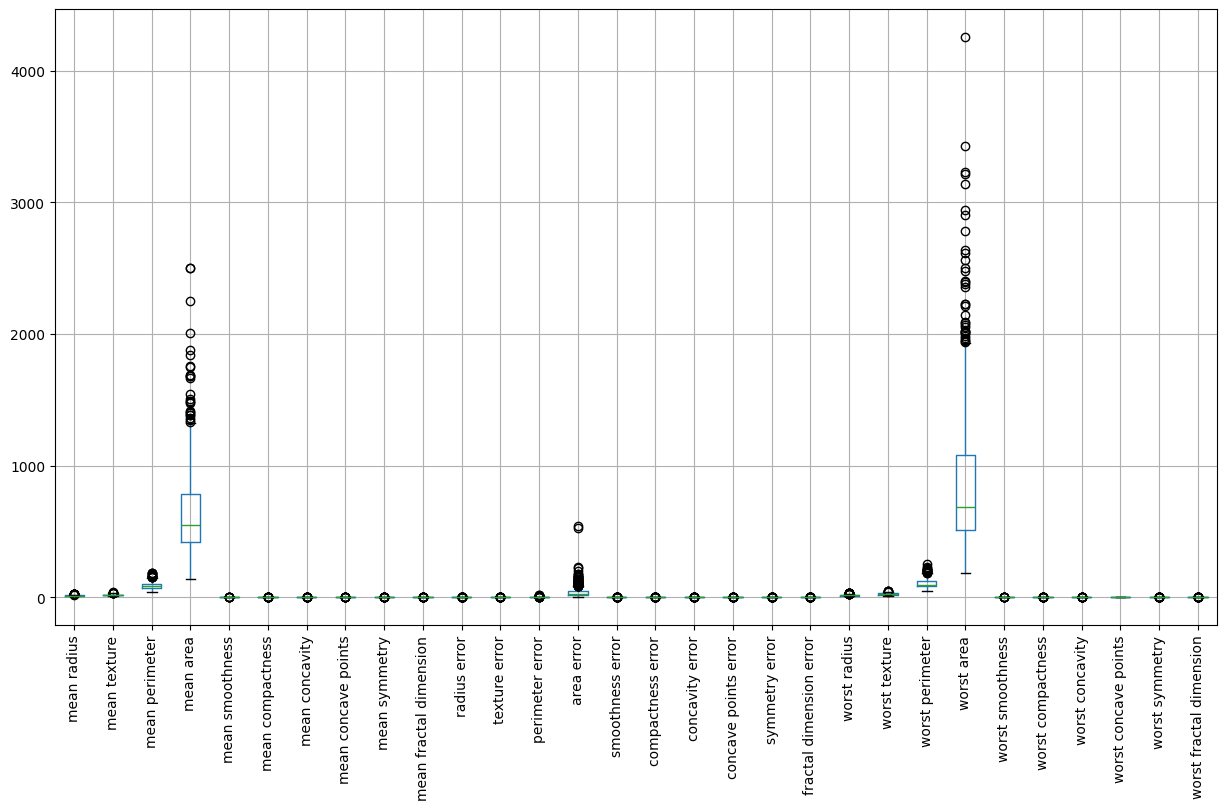

In [ ]:
plt.figure(figsize=(15, 8))
df.drop(columns=['target']).boxplot(rot=90)  # target 제외하고 확인
plt.show()

→ mean area와 worst area에서 이상치가 많이 발생한 것을 볼 수 있다.<br>
1) mean area는 각 세포가 차지하는 평균적인 면적을 의미 큰 값일 수록 악성종양일 확률이며 이상치라고 볼 수 없다.<br>
2) worst area는 종양의 크기가 가장 큰 세포의 크기이며 이 값 또한 이상치라고 볼 수 없다.

## 3. 상관분석

In [2]:
corr_df = df.corr()
print(corr_df['target'])

mean radius               -0.730029
mean texture              -0.415185
mean perimeter            -0.742636
mean area                 -0.708984
mean smoothness           -0.358560
mean compactness          -0.596534
mean concavity            -0.696360
mean concave points       -0.776614
mean symmetry             -0.330499
mean fractal dimension     0.012838
radius error              -0.567134
texture error              0.008303
perimeter error           -0.556141
area error                -0.548236
smoothness error           0.067016
compactness error         -0.292999
concavity error           -0.253730
concave points error      -0.408042
symmetry error             0.006522
fractal dimension error   -0.077972
worst radius              -0.776454
worst texture             -0.456903
worst perimeter           -0.782914
worst area                -0.733825
worst smoothness          -0.421465
worst compactness         -0.590998
worst concavity           -0.659610
worst concave points      -0

In [3]:
# 1) mean fractal dimension 0.012838
# 2) texture error 0.008303
# 3) symmetry error 0.006522
# 4) smoothness error 0.067016
# 5) fractal dimension error	-0.077972
# 5가지 columns 상관관계가 0에 가까움
# 상관관계 없다고 생각 ->  drop

df = df.drop(columns = ['mean fractal dimension','texture error', 'symmetry error', 'smoothness error','fractal dimension error'])
df.head(1)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,1.095,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0


In [4]:
corr_df = df.corr()
corr_df['target']
corr_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,0.679090,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,0.275869,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,0.691765,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,0.732562,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.301467,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.497473,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.631925,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.698050,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.303379,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
radius error,0.679090,0.275869,0.691765,0.732562,0.301467,0.497473,0.631925,0.698050,0.303379,1.000000,...,0.194799,0.719684,0.751548,0.141919,0.287103,0.380585,0.531062,0.094543,0.049559,-0.567134


<Axes: >

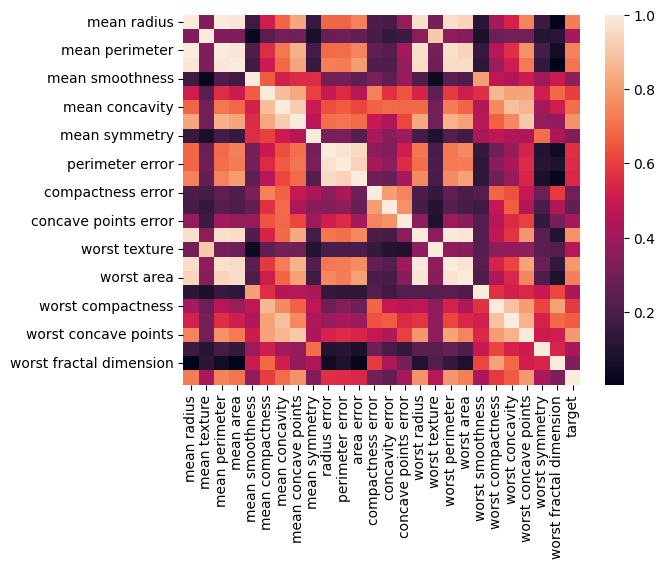

In [5]:
sns.heatmap(abs(corr_df))

## 4. 차원축소

In [6]:
# 1) mean radius, mean perimeter, mean area ,worst radius ,worst area, worst perimeter
# 상관관계가 1가까이로 높음 > 차원 축소
from sklearn.decomposition import PCA
selected = df.loc[:, ['mean radius', 'mean perimeter', 'mean area', 'worst radius', 'worst area', 'worst perimeter']]
pca = PCA(n_components = 0.95)
pca_1 = pca.fit_transform(selected)
pca_1.shape # (569, 1) 1차원 축소

# 잘 축소했는지 확인 코드 (0.95로 설정했으니 0.95이상이어야함)
# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)
# 누적 설명 분산 비율
print(pca.explained_variance_ratio_.cumsum())

[0.98361747]
[0.98361747]


In [7]:
# 축소 컬럼 추가
df['pca1'] = pca_1
# 축소 완료한 컬럼 drop
df.drop(columns = ['mean radius', 'mean perimeter', 'mean area', 'worst radius', 'worst area', 'worst perimeter'], inplace = True)
df

,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,perimeter error,area error,compactness error,...,concave points error,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,pca1
0,10.38,0.11840,0.27760,0.30010,0.14710,0.2419,1.0950,8.589,153.40,0.04904,...,0.01587,17.33,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,1155.682830
1,17.77,0.08474,0.07864,0.08690,0.07017,0.1812,0.5435,3.398,74.08,0.01308,...,0.01340,23.41,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,1269.235559
2,21.25,0.10960,0.15990,0.19740,0.12790,0.2069,0.7456,4.585,94.03,0.04006,...,0.02058,25.53,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,994.348425
3,20.38,0.14250,0.28390,0.24140,0.10520,0.2597,0.4956,3.445,27.23,0.07458,...,0.01867,26.50,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,-407.092877
4,14.34,0.10030,0.13280,0.19800,0.10430,0.1809,0.7572,5.438,94.44,0.02461,...,0.01885,16.67,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,928.810045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,22.39,0.11100,0.11590,0.24390,0.13890,0.1726,1.1760,7.673,158.70,0.02891,...,0.02454,26.40,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,1409.714202
565,28.25,0.09780,0.10340,0.14400,0.09791,0.1752,0.7655,5.203,99.04,0.02423,...,0.01678,38.25,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,1043.314926
566,28.08,0.08455,0.10230,0.09251,0.05302,0.1590,0.4564,3.425,48.55,0.03731,...,0.01557,34.12,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,314.489110
567,29.33,0.11780,0.27700,0.35140,0.15200,0.2397,0.7260,5.772,86.22,0.06158,...,0.01664,39.42,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,1123.987743


In [8]:
df.corr()

,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,perimeter error,area error,compactness error,...,concave points error,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,pca1
mean texture,1.000000,-0.023389,0.236702,0.302418,0.293464,0.071401,0.275869,0.281673,0.259845,0.191975,...,0.163851,0.912045,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185,0.340250
mean smoothness,-0.023389,1.000000,0.659123,0.521984,0.553695,0.557775,0.301467,0.296092,0.246552,0.318943,...,0.380676,0.036072,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560,0.200374
mean compactness,0.236702,0.659123,1.000000,0.883121,0.831135,0.602641,0.497473,0.548905,0.455653,0.738722,...,0.642262,0.248133,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534,0.511035
mean concavity,0.302418,0.521984,0.883121,1.000000,0.921391,0.500667,0.631925,0.660391,0.617427,0.670279,...,0.683260,0.299879,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360,0.684493
mean concave points,0.293464,0.553695,0.831135,0.921391,1.000000,0.462497,0.698050,0.710650,0.690299,0.490424,...,0.615634,0.292752,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614,0.820221
mean symmetry,0.071401,0.557775,0.602641,0.500667,0.462497,1.000000,0.303379,0.313893,0.223970,0.421659,...,0.393298,0.090651,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499,0.171675
radius error,0.275869,0.301467,0.497473,0.631925,0.698050,0.303379,1.000000,0.972794,0.951830,0.356065,...,0.513346,0.194799,0.141919,0.287103,0.380585,0.531062,0.094543,0.049559,-0.567134,0.752394
perimeter error,0.281673,0.296092,0.548905,0.660391,0.710650,0.313893,0.972794,1.000000,0.937655,0.416322,...,0.556264,0.200371,0.130054,0.341919,0.418899,0.554897,0.109930,0.085433,-0.556141,0.735552
area error,0.259845,0.246552,0.455653,0.617427,0.690299,0.223970,0.951830,0.937655,1.000000,0.284840,...,0.415730,0.196497,0.125389,0.283257,0.385100,0.538166,0.074126,0.017539,-0.548236,0.814791
compactness error,0.191975,0.318943,0.738722,0.670279,0.490424,0.421659,0.356065,0.416322,0.284840,1.000000,...,0.744083,0.143003,0.227394,0.678780,0.639147,0.483208,0.277878,0.590973,-0.292999,0.204855


<Axes: >

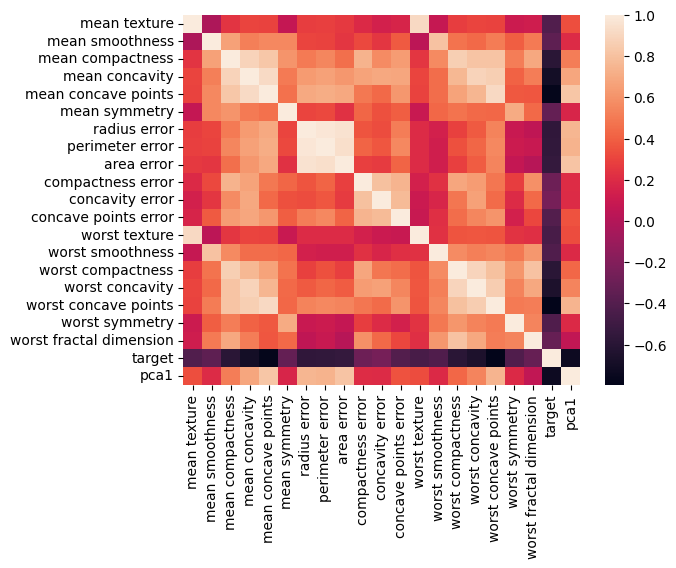

In [9]:
sns.heatmap(df.corr())

In [10]:
# 2) radius, perimeter, area error 차원 축소
selected = df.loc[:, ['radius error', 'perimeter error', 'area error']]
pca = PCA(n_components = 0.95)
pca_2 = pca.fit_transform(selected)
pca_2.shape

(569, 1)

In [11]:
df.drop(columns = ['radius error', 'perimeter error', 'area error'], inplace = True)
df['pca2'] = pca_2
df.head()

,mean texture,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,compactness error,concavity error,concave points error,worst texture,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,pca1,pca2
0,10.38,0.11840,0.27760,0.3001,0.14710,0.2419,0.04904,0.05373,0.01587,17.33,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,1155.682830,113.205267
1,17.77,0.08474,0.07864,0.0869,0.07017,0.1812,0.01308,0.01860,0.01340,23.41,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1269.235559,33.736033
2,21.25,0.10960,0.15990,0.1974,0.12790,0.2069,0.04006,0.03832,0.02058,25.53,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,994.348425,53.718995
3,20.38,0.14250,0.28390,0.2414,0.10520,0.2597,0.07458,0.05661,0.01867,26.50,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,-407.092877,-13.070851
4,14.34,0.10030,0.13280,0.1980,0.10430,0.1809,0.02461,0.05688,0.01885,16.67,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,928.810045,54.164225


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean texture             569 non-null    float64
 1   mean smoothness          569 non-null    float64
 2   mean compactness         569 non-null    float64
 3   mean concavity           569 non-null    float64
 4   mean concave points      569 non-null    float64
 5   mean symmetry            569 non-null    float64
 6   compactness error        569 non-null    float64
 7   concavity error          569 non-null    float64
 8   concave points error     569 non-null    float64
 9   worst texture            569 non-null    float64
 10  worst smoothness         569 non-null    float64
 11  worst compactness        569 non-null    float64
 12  worst concavity          569 non-null    float64
 13  worst concave points     569 non-null    float64
 14  worst symmetry           5

<Axes: >

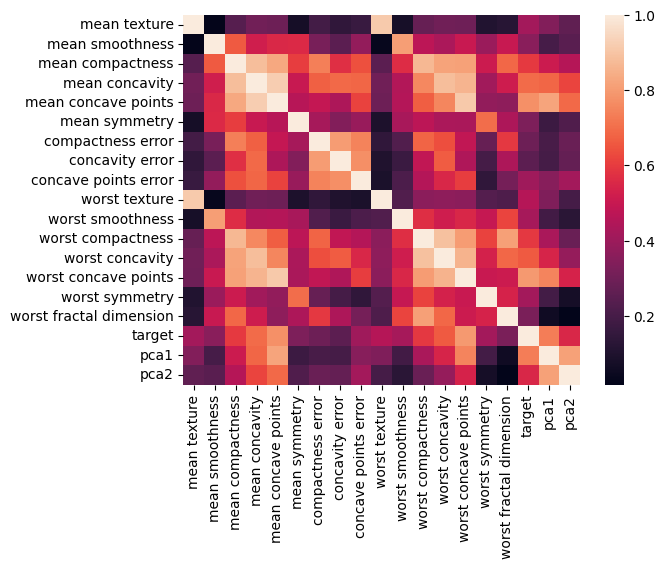

In [13]:
sns.heatmap(abs(df.corr()))

## 5. 불균형 데이터 처리

In [17]:
# target 열의 고유값과 그 고유값별 행의 갯수를 출력
print(df['target'].value_counts())

target
1    357
0    212
Name: count, dtype: int64


In [19]:
# SMOTE 오버샘플링
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='auto', random_state=42)

X = df.drop(columns=['target'])
y = df['target']

X_smote, y_smote = smote.fit_resample(X, y)

# SMOTE 적용 전후의 target 클래스 분포 확인
print("Before SMOTE:", y.value_counts())
print("\nAfter SMOTE:", y_smote.value_counts())

Before SMOTE: target
1    357
0    212
Name: count, dtype: int64

After SMOTE: target
0    357
1    357
Name: count, dtype: int64


<Axes: xlabel='pca1', ylabel='pca2'>

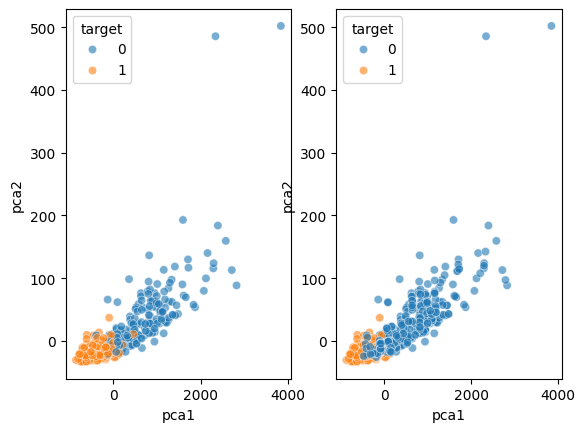

In [23]:
# 데이터프레임으로 변환
df_smote = pd.DataFrame(X_smote)
df_smote['target'] = y_smote
df_smote['target'].value_counts()

# pca 1 - mean radius, mean perimeter, mean area ,worst radius ,worst area, worst perimeter
# pca 2 - radius, perimeter, area error
# 산점도 그리기
# df_smote에서 target=0의 값이 증가한 것을 볼 수 있음
plt.subplot(1,2,1)
sns.scatterplot(data=df, x = 'pca1', y = 'pca2', hue = 'target', alpha = 0.6)
plt.subplot(1,2,2)
sns.scatterplot(data=df_smote, x = 'pca1', y = 'pca2', hue = 'target', alpha = 0.6)